# Deep Learning Project

In [ ]:
# TensorFlow and Keras for model building
import tensorflow as tf
import keras
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50, Xception, EfficientNetV2S # I used EfficientNetV2S Model
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import L2
from tensorflow.keras.optimizers import Adam, RMSprop
from keras.utils import plot_model

# Other utilities
import os
import numpy as np # This is for converting numpy arrays
import matplotlib.pyplot as plt # This is for plotting

Constants

In [ ]:
IMAGE_SIZE = 299 # 299x299
BATCH_SIZE = 64 
CLASSES = 2
EPOCHS = 20

# Dataset directory declaration

📥 Dataset Source:

✅ Option 1: Download dataset manually from Kaggle
Example: https://www.kaggle.com/datasets (Choose your dataset)
After downloading, extract it to your working directory, e.g., './dataset_folder'

✅ Option 2 (Optional Advanced): Use Kaggle API to download directly
`!kaggle datasets download -d username/dataset-name`
`!unzip dataset-name.zip -d ./dataset_folder`

In [97]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
"./Tomatoes2", #Replace with actual dataset file path
shuffle=True,
image_size=(IMAGE_SIZE, IMAGE_SIZE),
batch_size=BATCH_SIZE
)

#Calls and Displays class names from dataset
class_names = dataset.class_names
class_names

Found 2000 files belonging to 2 classes.


['Not Tomato', 'Tomato']

# Plots images from their respective classes

This Assumes 'dataset' is a tf.data.Dataset object and 'class_names' contains your dataset's class labels

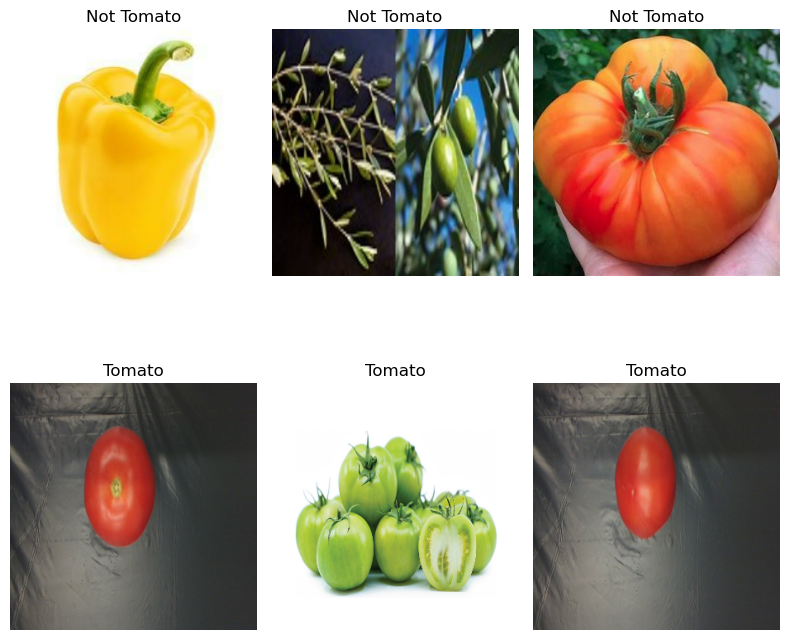

In [99]:
import matplotlib.pyplot as plt


# Varies: Update this list based on YOUR dataset class names
class_names_of_interest = ['Not Tomato', 'Tomato'] #Class sizes may vary depending on your dataset

# Ensure these class names match EXACTLY with what's inside dataset.class_names
class_indices = [class_names.index(name) for name in class_names_of_interest]  # Get class indices

# Initialize a dictionary to store a few images per class
healthy_images = {name: [] for name in class_names_of_interest}

# Collect 3 sample images per selected class (Can change number if you want more/less images)
for images, labels in dataset:
    for i in range(len(labels)):
        label = labels[i].numpy()
        
        # Critical: Ensure your label mapping logic works (Some datasets may return one-hot encoded labels)
        if label in class_indices and len(healthy_images[class_names[label]]) < 3:
            healthy_images[class_names[label]].append((images[i], labels[i]))
            
        # Varies: Stop when 3 samples for each class are collected (Change 3 if you want more/less)
        if all(len(healthy_images[name]) == 3 for name in class_names_of_interest):
            break
    if all(len(healthy_images[name]) == 3 for name in class_names_of_interest):
        break

# Plot the images
plt.figure(figsize=(8, 8))  # 🔄 Varies: Adjust figure size based on number of classes or samples per class
for i, name in enumerate(class_names_of_interest):
    for j, (image, label) in enumerate(healthy_images[name]):
        ax = plt.subplot(len(class_names_of_interest), 3, i * 3 + j + 1)  # Varies: '3' is samples per class
        plt.imshow(image.numpy().astype("uint8"))
        plt.title(name)
        plt.axis("off")

plt.tight_layout()
plt.show()


# Splitting Dataset to 70-20-10, training, validation and test respectively
### Apply Augmentation
You can change the datasplit according to how much you need

CHANGE VALUES OF `train_split`, `val_split`, `test_split` from the `get_dataset_partitions_tf()` method according to your Splitting Ratio

In [100]:
# Function for augmenting images using preprocessing layers
def Crop(image):
    image = keras.layers.RandomCrop(IMAGE_SIZE, IMAGE_SIZE)(image)  # Randomly crop image

    return image

def Rotate(image):
    image = keras.layers.RandomRotation(0.4)(image)  # Randomly rotate image

    return image

def Contrast(image):
    image = keras.layers.RandomContrast(0.2)(image)  # Randomly adjust contrast

    return image

def Flip(image):
    image = keras.layers.RandomFlip("horizontal_and_vertical")(image)  # Randomly flip image

    return image

def Brightness(image):
    image = keras.layers.RandomBrightness([0.1, 0.4])(image)  # Randomly adjust brightness

    return image

# Load and augment the training set

def get_dataset_partitions_tf(ds, train_split=0.7, val_split=0.20, test_split=0.10, shuffle=True, shuffle_size=10000, augment_data=True):
    
    # Get length of dataset
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)  # Shuffle dataset before splitting
    
    # Compute percentage accordingly from dataset size
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    # Split the dataset into training, validation, and test sets
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    if augment_data:
    # Apply augmentation only to the training set
        cropped_train_ds = train_ds.map(lambda x, y: (Crop(x), y), num_parallel_calls=tf.data.AUTOTUNE)
        rotated_train_ds = train_ds.map(lambda x, y: (Rotate(x), y), num_parallel_calls=tf.data.AUTOTUNE)
        contrasted_train_ds = train_ds.map(lambda x, y: (Contrast(x), y), num_parallel_calls=tf.data.AUTOTUNE)
        flipped_train_ds = train_ds.map(lambda x, y: (Flip(x), y), num_parallel_calls=tf.data.AUTOTUNE)
        brightness_train_ds = train_ds.map(lambda x, y: (Brightness(x), y), num_parallel_calls=tf.data.AUTOTUNE)
        
    # Concatenate the original training data with the augmented data
        train_ds = train_ds.concatenate(cropped_train_ds)
        train_ds = train_ds.concatenate(rotated_train_ds)
        train_ds = train_ds.concatenate(contrasted_train_ds)
        train_ds = train_ds.concatenate(flipped_train_ds)
        train_ds = train_ds.concatenate(brightness_train_ds)
    
    return train_ds, val_ds, test_ds

# Assuming you already loaded your dataset into `dataset`
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

# Shuffling and Cache the dataset for faster model training

In [101]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

# Load Model

In [102]:
your_model = keras.Sequential()

base_model = EfficientNetV2S(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), pooling='avg', classes=2)


# REPLACE '4' from dense layer accoringly to how much classifiers you have in your dataset
predictions = Dense(2, activation='softmax')

for layer in base_model.layers:
    layer.trainable = False

# Add or remove layers to your liking
# You can achieve high results via experimental process

your_model.add(base_model) # DO NOT REMOVE THIS, this is the layer for your actual model
your_model.add(layers.Flatten())

# Regularization and Dropout
your_model.add(layers.Dense(512, activation='relu', kernel_regularizer=L2(0.003)))
your_model.add(layers.BatchNormalization())
your_model.add(layers.Dropout(0.5))

your_model.add(layers.Dense(256, activation='relu', kernel_regularizer=L2(0.003)))
your_model.add(layers.BatchNormalization())
your_model.add(layers.Dropout(0.4))

your_model.add(layers.Dense(128, activation='relu', kernel_regularizer=L2(0.001)))
your_model.add(layers.BatchNormalization())
your_model.add(layers.Dropout(0.3))

your_model.add(layers.Dense(64, activation='relu', kernel_regularizer=L2(0.001)))
your_model.add(layers.BatchNormalization())
your_model.add(layers.Dropout(0.2))

your_model.add(layers.Dense(32, activation='relu'))
your_model.add(layers.Dropout(0.1))

your_model.add(predictions) # DO NOT REMOVE THIS, this layer is responsible for your predictions

your_model.summary() # This simply summarizes and shows the entire layers of your model

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-s (Functiona  (None, 1280)             20331360  
 l)                                                              
                                                                 
 flatten_7 (Flatten)         (None, 1280)              0         
                                                                 
 dense_48 (Dense)            (None, 512)               655872    
                                                                 
 batch_normalization_28 (Bat  (None, 512)              2048      
 chNormalization)                                                
                                                                 
 dropout_29 (Dropout)        (None, 512)               0         
                                                                 
 dense_49 (Dense)            (None, 256)              

In [ ]:
reduce_lr = ReduceLROnPlateau( # Automatically reduce learning rate while training based on factor and patience
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
# Compile the model with an Adam optimizer and categorical crossentropy loss
your_model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])


# Time to train with Model.fit() 

In [105]:
# Train the model on the dataset
history = your_model.fit(
    train_ds,
    epochs=EPOCHS,  # You can increase the number of epochs based on your dataset
    validation_data=val_ds,
    callbacks=[reduce_lr]
)

Epoch 1/20
132/132 [==============================] - 123s 602ms/step - loss: 3.1917 - accuracy: 0.9471 - val_loss: 2.5067 - val_accuracy: 0.9911 - lr: 0.0010
Epoch 2/20
132/132 [==============================] - 65s 484ms/step - loss: 1.9663 - accuracy: 0.9916 - val_loss: 1.4791 - val_accuracy: 0.9970 - lr: 0.0010
Epoch 3/20
132/132 [==============================] - 63s 475ms/step - loss: 1.1887 - accuracy: 0.9905 - val_loss: 0.9237 - val_accuracy: 0.9881 - lr: 0.0010
Epoch 4/20
132/132 [==============================] - 63s 477ms/step - loss: 0.7472 - accuracy: 0.9936 - val_loss: 0.5785 - val_accuracy: 0.9970 - lr: 0.0010
Epoch 5/20
132/132 [==============================] - 63s 480ms/step - loss: 0.5024 - accuracy: 0.9922 - val_loss: 0.4086 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 6/20
132/132 [==============================] - 63s 478ms/step - loss: 0.3693 - accuracy: 0.9925 - val_loss: 0.3519 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 7/20
132/132 [==============================]

### The recent model performance is declared on the `history` variable, so all of our metrics can be accessed through the `history` variable

In [106]:
#show highest accuracy and validation accuracy show lowest loss and validation loss and latest of each
print("Highest Accuracy: ", max(history.history['accuracy']))
print("Highest Validation Accuracy: ", max(history.history['val_accuracy']))
print("Lowest Loss: ", min(history.history['loss']))
print("Lowest Validation Loss: ", min(history.history['val_loss']))
print("Final Accuracy: ", history.history['accuracy'][-1])
print("Final Validation Accuracy: ", history.history['val_accuracy'][-1])
print("Final Loss: ", history.history['loss'][-1])
print("Final Validation Loss: ", history.history['val_loss'][-1])

Highest Accuracy:  0.9956647157669067
Highest Validation Accuracy:  1.0
Lowest Loss:  0.11030701547861099
Lowest Validation Loss:  0.09477388113737106
Final Accuracy:  0.9956647157669067
Final Validation Accuracy:  1.0
Final Loss:  0.11030701547861099
Final Validation Loss:  0.09477388113737106


# Making a Prediction (Not Fine Tuned)

1/1 [==============================] - 0s 49ms/step


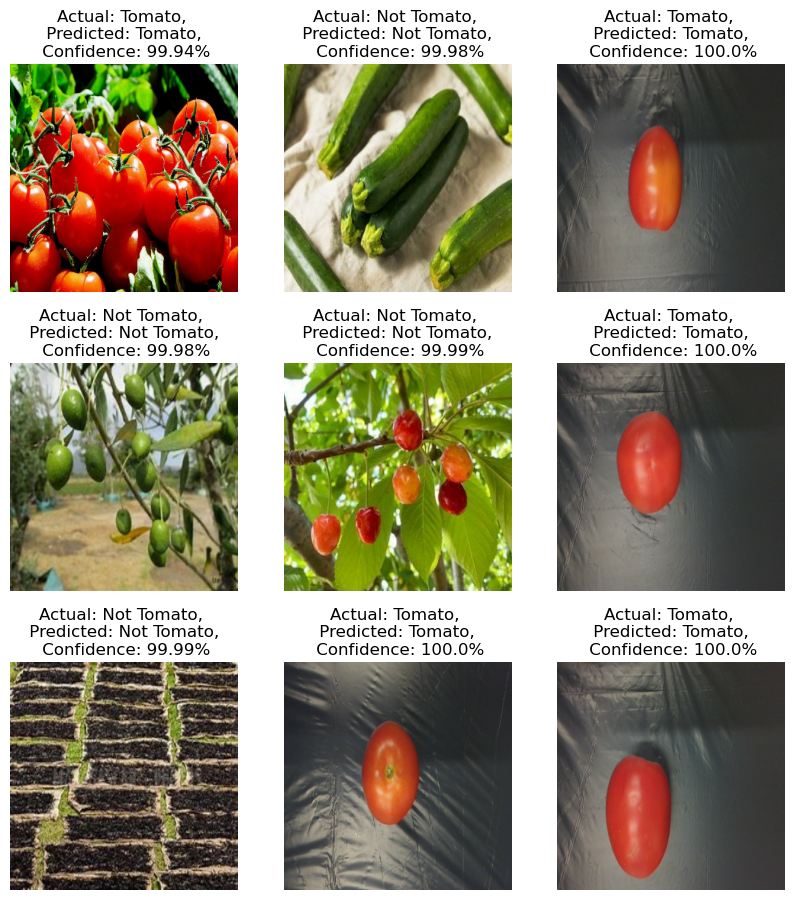

In [109]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0) #Create a batch

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

plt.figure(figsize=(10, 11))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        
        predicted_class, confidence = predict(your_model, images[i].numpy())
        actual_class = class_names[labels[i]]
        
        plt.title(f"Actual: {actual_class}, \n Predicted: {predicted_class}, \n Confidence: {confidence}%")
        
        plt.axis("off")

# Model Evualuation

In [110]:
scores = your_model.evaluate(test_ds) # No Fine-Tuning

4/4 [==============================] - 2s 461ms/step - loss: 0.0941 - accuracy: 1.0000


In [115]:
# code to view f1 score and other metrics
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

y_pred = your_model.predict(test_ds)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)
f1 = f1_score(y_true, y_pred, average='weighted')
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
accuracy = accuracy_score(y_true, y_pred)
print(f'F1 Score: {f1}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'Accuracy: {accuracy}')
print(classification_report(y_true, y_pred))

4/4 [==============================] - 1s 436ms/step
F1 Score: 0.796875
Precision: 0.796875
Recall: 0.796875
Accuracy: 0.796875
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       131
           1       0.79      0.79      0.79       125

    accuracy                           0.80       256
   macro avg       0.80      0.80      0.80       256
weighted avg       0.80      0.80      0.80       256



4/4 [==============================] - 1s 440ms/step


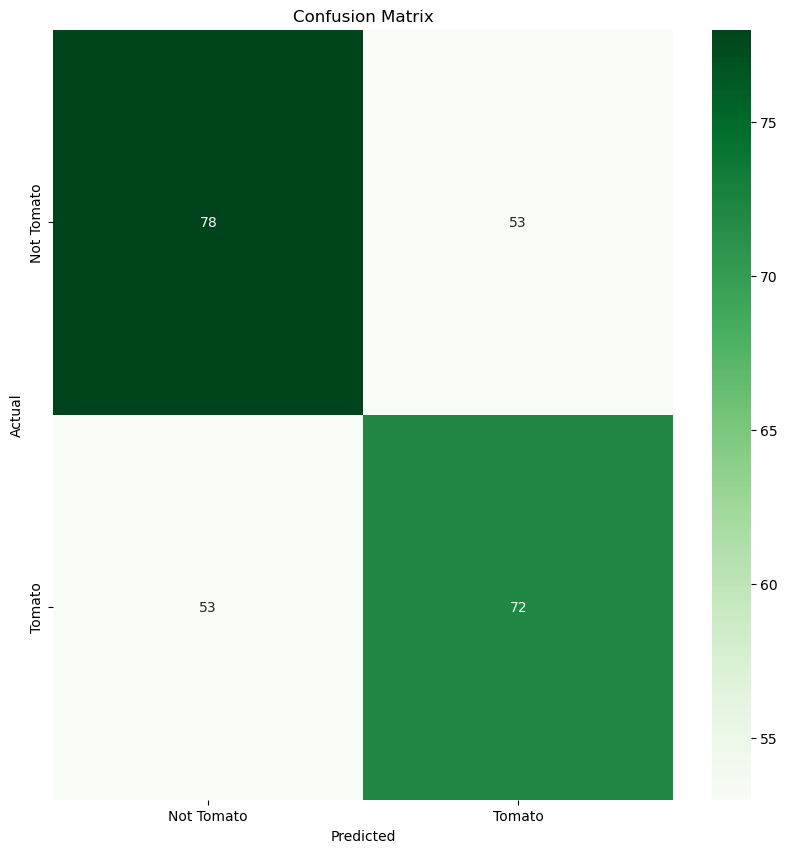

In [117]:
#code block to show confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = your_model.predict(test_ds)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='g', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Plotting History | No Fine-Tuning

In [118]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

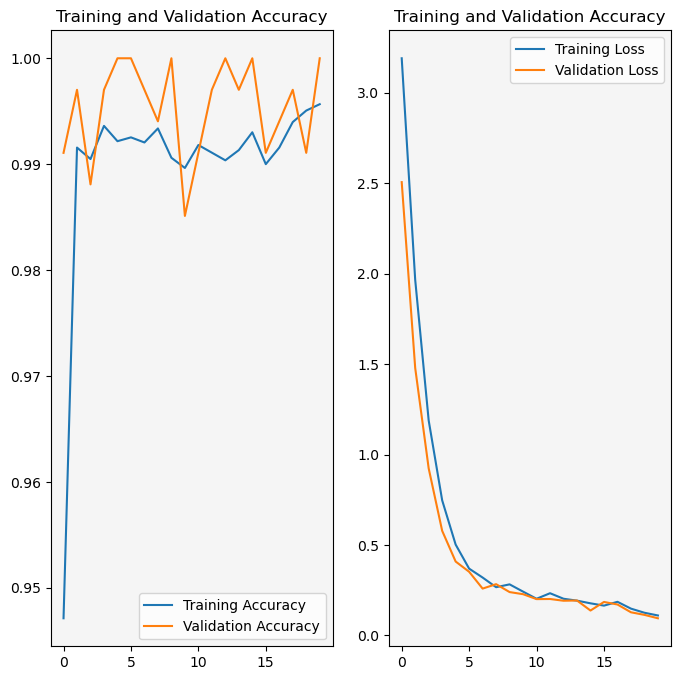

In [119]:
completed_epochs = len(history.history['accuracy'])

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(completed_epochs), acc, label='Training Accuracy')
plt.plot(range(completed_epochs), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid(False)
plt.gca().set_facecolor('#F5F5F5')

plt.subplot(1, 2, 2)
plt.plot(range(completed_epochs), loss, label='Training Loss')
plt.plot(range(completed_epochs), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Accuracy')
plt.grid(False)
plt.gca().set_facecolor('#F5F5F5')
plt.show()

# Saving Model (NOT FINE TUNED)

In [123]:
model_files = [i for i in os.listdir("./modelsNFT") if i.isdigit()]
model_version = max([int(i) for i in model_files] + [0]) + 1
your_model.save(f"./modelsNFT/{model_version}")

INFO:tensorflow:Assets written to: ./modelsNFT/2\assets


INFO:tensorflow:Assets written to: ./modelsNFT/2\assets


# Fine Tuning
## Un-Freeze and Fine-tune the model

In [124]:
base_model = your_model.layers[0]

In [ ]:
# Unfreeze only a subset of layers

# Freeze all layers except the last 50 layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Unfreeze the last 50 layers
for layer in base_model.layers[-50:]:
    layer.trainable = True

your_model.compile(optimizer=Adam(learning_rate=0.0001), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

your_model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-s (Functiona  (None, 1280)             20331360  
 l)                                                              
                                                                 
 flatten_7 (Flatten)         (None, 1280)              0         
                                                                 
 dense_48 (Dense)            (None, 512)               655872    
                                                                 
 batch_normalization_28 (Bat  (None, 512)              2048      
 chNormalization)                                                
                                                                 
 dropout_29 (Dropout)        (None, 512)               0         
                                                                 
 dense_49 (Dense)            (None, 256)              

Continue training the entire model

In [127]:
history_finetune = your_model.fit(
    train_ds,
    epochs=5,  # Additional epochs for fine-tuning
    batch_size = BATCH_SIZE,
    validation_data=val_ds,
)

Epoch 1/5
132/132 [==============================] - 113s 718ms/step - loss: 0.0999 - accuracy: 0.9943 - val_loss: 0.0776 - val_accuracy: 1.0000
Epoch 2/5
132/132 [==============================] - 71s 538ms/step - loss: 0.0807 - accuracy: 0.9980 - val_loss: 0.0676 - val_accuracy: 1.0000
Epoch 3/5
132/132 [==============================] - 71s 539ms/step - loss: 0.0668 - accuracy: 0.9988 - val_loss: 0.0582 - val_accuracy: 1.0000
Epoch 4/5
132/132 [==============================] - 71s 541ms/step - loss: 0.0597 - accuracy: 0.9988 - val_loss: 0.0521 - val_accuracy: 1.0000
Epoch 5/5
132/132 [==============================] - 71s 541ms/step - loss: 0.0559 - accuracy: 0.9987 - val_loss: 0.0470 - val_accuracy: 1.0000


In [128]:
#show highest accuracy and validation accuracy show lowest loss and validation loss and latest of each
print("Highest Accuracy: ", max(history_finetune.history['accuracy']))
print("Highest Validation Accuracy: ", max(history_finetune.history['val_accuracy']))
print("Lowest Loss: ", min(history_finetune.history['loss']))
print("Lowest Validation Loss: ", min(history_finetune.history['val_loss']))
print("Final Accuracy: ", history_finetune.history['accuracy'][-1])
print("Final Validation Accuracy: ", history_finetune.history['val_accuracy'][-1])
print("Final Loss: ", history_finetune.history['loss'][-1])
print("Final Validation Loss: ", history_finetune.history['val_loss'][-1])

Highest Accuracy:  0.998795747756958
Highest Validation Accuracy:  1.0
Lowest Loss:  0.05590537190437317
Lowest Validation Loss:  0.04697993025183678
Final Accuracy:  0.9986753463745117
Final Validation Accuracy:  1.0
Final Loss:  0.05590537190437317
Final Validation Loss:  0.04697993025183678


In [136]:
# code to view f1 score and other metrics
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# code to view f1 score and other metrics
y_pred = your_model.predict(test_ds)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)
f1 = f1_score(y_true, y_pred, average='weighted')
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
accuracy = accuracy_score(y_true, y_pred)
print(f'F1 Score: {f1}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'Accuracy: {accuracy}')
print(classification_report(y_true, y_pred))

4/4 [==============================] - 1s 444ms/step
F1 Score: 0.796875
Precision: 0.796875
Recall: 0.796875
Accuracy: 0.796875
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       131
           1       0.79      0.79      0.79       125

    accuracy                           0.80       256
   macro avg       0.80      0.80      0.80       256
weighted avg       0.80      0.80      0.80       256



In [137]:
scores = your_model.evaluate(test_ds) # With Fine Tuning

4/4 [==============================] - 2s 450ms/step - loss: 0.0470 - accuracy: 1.0000


# Plotting History | With Fine-Tuning

In [138]:
acc = history_finetune.history['accuracy']
val_acc = history_finetune.history['val_accuracy']

loss = history_finetune.history['loss']
val_loss = history_finetune.history['val_loss']

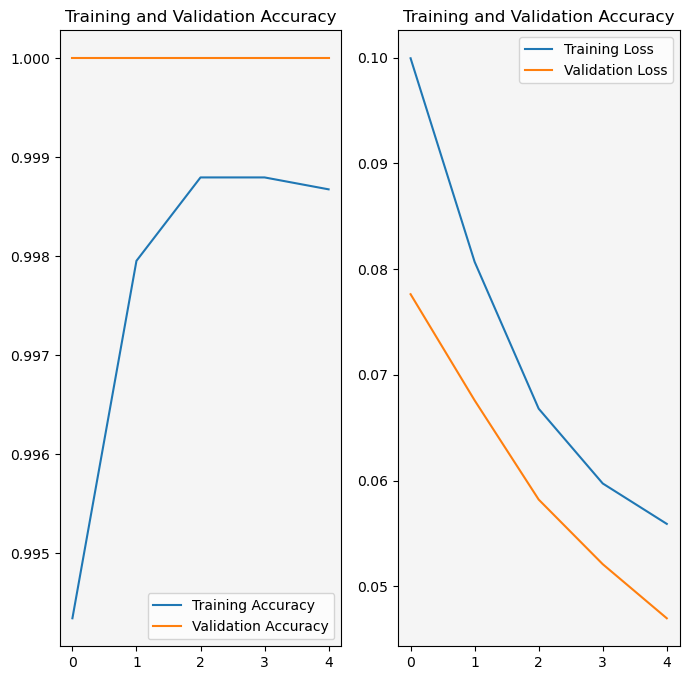

In [139]:
completed_epochs2 = len(history_finetune.history['accuracy'])

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(completed_epochs2), acc, label='Training Accuracy')
plt.plot(range(completed_epochs2), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid(False)
plt.gca().set_facecolor('#F5F5F5')

plt.subplot(1, 2, 2)
plt.plot(range(completed_epochs2), loss, label='Training Loss')
plt.plot(range(completed_epochs2), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Accuracy')
plt.grid(False)
plt.gca().set_facecolor('#F5F5F5')
plt.show()

# Making a Prediction (Fine Tuned)

1/1 [==============================] - 0s 51ms/step


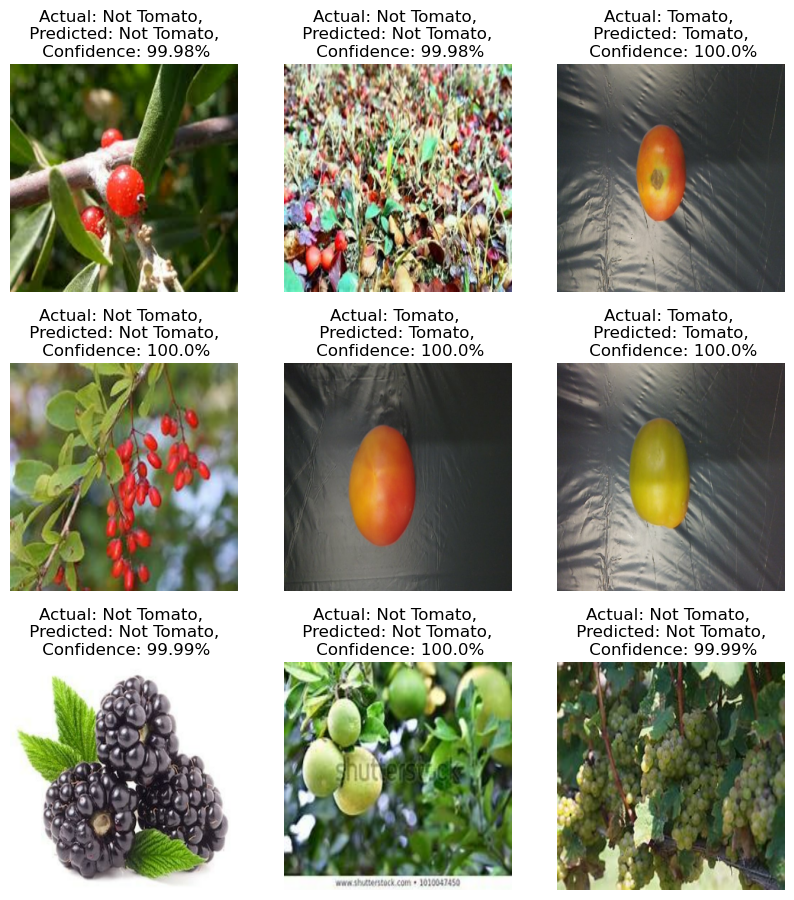

In [144]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0) #Create a batch

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

plt.figure(figsize=(10, 11))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        
        predicted_class, confidence = predict(your_model, images[i].numpy())
        actual_class = class_names[labels[i]]
        
        plt.title(f"Actual: {actual_class}, \n Predicted: {predicted_class}, \n Confidence: {confidence}%")
        
        plt.axis("off")

Confusion Matrix

4/4 [==============================] - 1s 480ms/step


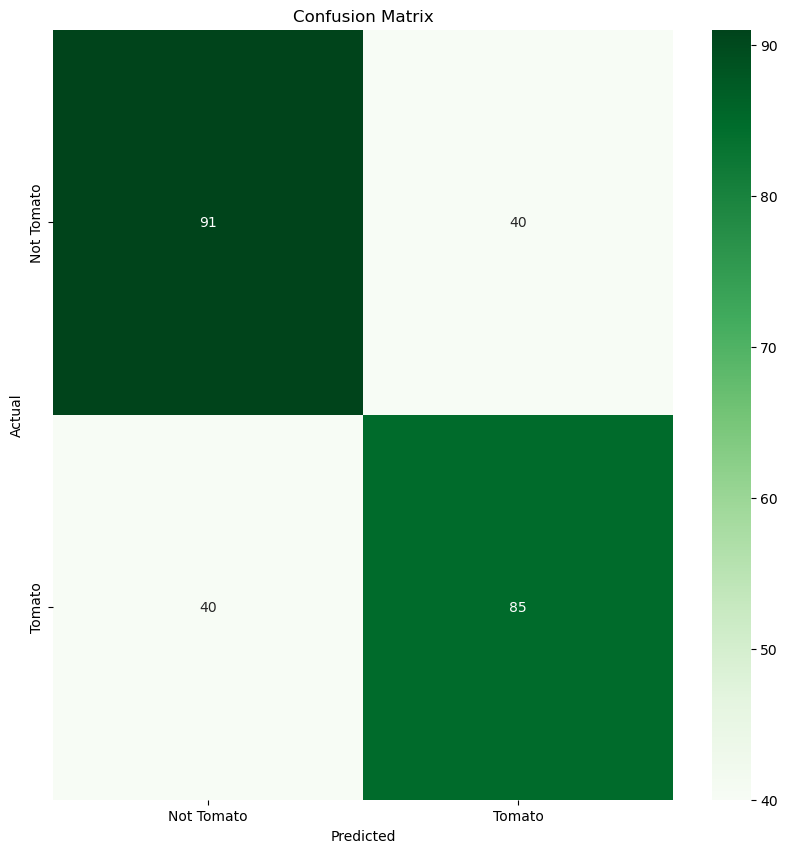

In [142]:
#code block to show confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = your_model.predict(test_ds)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='g', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Saving Model (FINE TUNED)

In [143]:
model_version = max([int(i) for i in os.listdir("./modelsFT") + [0]]) + 1
your_model.save(f"./modelsFT/{model_version}")

INFO:tensorflow:Assets written to: ./modelsFT/2\assets


INFO:tensorflow:Assets written to: ./modelsFT/2\assets
